# PyTorch Basics Tutorial
A comprehensive guide to getting started with PyTorch

In [1]:
import torch
import torch.nn as nn # pytorch neural network module
import torch.nn.functional as F # pytorch functional module for activation functions, etc.
import torch.optim as optim # pytorch optimization module

import matplotlib.pyplot as plt # for plotting

In [2]:
print("1. TENSORS - The Foundation of PyTorch")

# Creating tensors (similar to NumPy arrays)
# From lists
tensor_1d = torch.tensor([1, 2, 3, 4, 5])
tensor_2d = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(f"1D Tensor: {tensor_1d}")
print(f"2D Tensor:\n{tensor_2d}")

# Creating tensors with specific values
zeros = torch.zeros(3, 3)  # 3x3 matrix of zeros
ones = torch.ones(2, 4)    # 2x4 matrix of ones
random_tensor = torch.randn(3, 3)  # 3x3 matrix with random normal distribution
print(f"\nZeros:\n{zeros}")
print(f"\nOnes:\n{ones}")
print(f"\nRandom tensor:\n{random_tensor}")

# Tensor properties
print(f"\nTensor shape: {tensor_2d.shape}")
print(f"Tensor dtype: {tensor_2d.dtype}")
print(f"Tensor device: {tensor_2d.device}")

1. TENSORS - The Foundation of PyTorch
1D Tensor: tensor([1, 2, 3, 4, 5])
2D Tensor:
tensor([[1, 2, 3],
        [4, 5, 6]])

Zeros:
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

Ones:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])

Random tensor:
tensor([[ 1.1108,  0.7908, -1.8002],
        [-1.3711,  1.3900, -0.4236],
        [ 0.3843,  0.7542,  0.5986]])

Tensor shape: torch.Size([2, 3])
Tensor dtype: torch.int64
Tensor device: cpu


In [3]:
print("2. TENSOR OPERATIONS")

# Basic math operations
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print(f"a: {a}")
print(f"b: {b}")
print(f"a + b: {a + b}")
print(f"a * b: {a * b}")  # Element-wise multiplication
print(f"a.dot(b): {a.dot(b)}")  # Dot product results a scalar value
# dot product of matrices are called matrix multiplication

# Matrix operations
matrix_a = torch.randn(3, 4)
matrix_b = torch.randn(4, 2)
matrix_product = torch.matmul(matrix_a, matrix_b)  # Matrix multiplication, also done with @ operator: matrix_a @ matrix_b
print(f"\nMatrix A shape: {matrix_a.shape}")
print(f"Matrix B shape: {matrix_b.shape}")
print(f"Matrix Product shape: {matrix_product.shape}")

# Reshaping tensors
original = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])
print(f"\nOriginal shape: {original.shape}")
reshaped = original.view(4, 2)  # Reshape to 4x2 by first flattening to 1D and then reshaping
print(f"Reshaped to 4x2:\n{reshaped}")

2. TENSOR OPERATIONS
a: tensor([1., 2., 3.])
b: tensor([4., 5., 6.])
a + b: tensor([5., 7., 9.])
a * b: tensor([ 4., 10., 18.])
a.dot(b): 32.0

Matrix A shape: torch.Size([3, 4])
Matrix B shape: torch.Size([4, 2])
Matrix Product shape: torch.Size([3, 2])

Original shape: torch.Size([2, 4])
Reshaped to 4x2:
tensor([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]])


In [4]:
print("3. AUTOGRAD - Automatic Differentiation")

# Gradient tracking
# Tensors created via factory methods like torch.tensor(), torch.zeros(), torch.ones() or torch.randn() have requires_grad=False by default.
# any weights or biases created inside a PyTorch neural network layer (like nn.Linear or nn.Conv2d) have requires_grad=True by default.
# If you perform a mathematical operation combining a requires_grad=False tensor and a requires_grad=True tensor, the resulting output tensor will automatically have requires_grad=True

x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Perform operations
z = x**2 + y**3
print(f"z = x² + y³ = {z.item()}")

# Compute gradients
z.backward()  # Computes dz/dx and dz/dy

print(f"dz/dz = 1 = {z.grad}") # gives warning because it is non leaf tensor
print(f"dz/dx = 2x = {x.grad}")
print(f"dz/dy = 3y² = {y.grad}")


# Simple example
a = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(2.0, requires_grad=True)
c = torch.tensor(3.0, requires_grad=True)
d = a * b + c

d.backward()

print(f"\n\nGradient of d w.r.t a: {a.grad}")  # Should be b
print(f"Gradient of d w.r.t b: {b.grad}")  # Should be a
print(f"Gradient of d w.r.t c: {c.grad}")  # Should be 1

3. AUTOGRAD - Automatic Differentiation
z = x² + y³ = 31.0
dz/dz = 1 = None
dz/dx = 2x = 4.0
dz/dy = 3y² = 27.0


Gradient of d w.r.t a: 2.0
Gradient of d w.r.t b: 1.0
Gradient of d w.r.t c: 1.0


/tmp/ipykernel_15907/3554582537.py:18: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1781053922290/work/build/aten/src/ATen/core/TensorBody.h:494.)
  print(f"dz/dz = 1 = {z.grad}") # gives warning because it is non leaf tensor


In [5]:
# Leaf vs Non-leaf Tensors
# leaf tensors are the foundational inputs of your computational graph, while non-leaf tensors are intermediate results created by mathematical operations
# PyTorch optimizes memory by only saving gradients for leaf tensors during the .backward() step. Gradients for non-leaf tensors are discarded immediately after use

# Leaf Tensors are :
# Any tensor you create directly using factory methods (like torch.randn(), torch.ones()) where requires_grad=True 
# All weights and biases in PyTorch layers (e.g., nn.Linear.weight), which are wrapped as nn.Parameter.
# Any tensor with requires_grad=False is automatically considered a leaf tensor.

# Non-leaf Tensors are :
# any intermediate variable produced during the forward pass.
# The output of an addition: z = x + y (where z is non-leaf).
# The output of a layer: output = model(inputs).

a = torch.tensor(1.0, requires_grad=True) # Leaf tensor
b = torch.tensor(2.0, requires_grad=True) # Leaf tensor

c = a * b # Non-leaf tensor
# If you ever absolutely need to inspect the gradient of a non-leaf tensor during debugging, you can call y.retain_grad()
c.retain_grad() # Retain gradient for non-leaf tensor

d = 3 * c # Non-leaf tensor
# d.retain_grad() # Retain gradient for non-leaf tensor

d.backward()

c.grad, d.grad

/tmp/ipykernel_15907/1607337277.py:27: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1781053922290/work/build/aten/src/ATen/core/TensorBody.h:494.)
  c.grad, d.grad


(tensor(3.), None)

In [6]:
print("4. BUILDING A SIMPLE NEURAL NETWORK")

# Define a simple neural network
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Define layers
        self.fc1 = nn.Linear(10, 20)  # Input: 10 features, Output: 20
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(20, 5)   # Input: 20, Output: 5
        self.fc3 = nn.Linear(5, 1)    # Input: 5, Output: 1
    
    def forward(self, x):
        # Define forward pass
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

# Create model instance
model = SimpleNet()
print("Model architecture:")
print(model)

# Check model parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

4. BUILDING A SIMPLE NEURAL NETWORK
Model architecture:
SimpleNet(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=5, bias=True)
  (fc3): Linear(in_features=5, out_features=1, bias=True)
)

Total parameters: 331


5. TRAINING A MODEL - Complete Example
Training a linear regression model...
True relationship: y = 3x + 2
Epoch [20/100], Loss: 49.2959
Epoch [40/100], Loss: 6.3420
Epoch [60/100], Loss: 3.4448
Epoch [80/100], Loss: 3.1945
Epoch [100/100], Loss: 3.1495

Learned parameters:
Weight (should be ~3): 3.0007
Bias (should be ~2): 1.9091


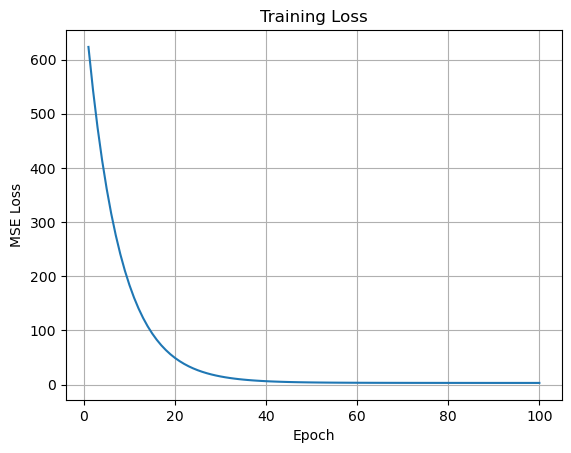

In [7]:
print("5. TRAINING A MODEL - Complete Example")

# Create synthetic data for a simple regression problem
# y = 3x + 2 + noise
torch.manual_seed(42)
X_train = torch.randn(100, 1) * 10  # 100 samples, 1 feature, tensor of shape (100, 1)
y_train = 3 * X_train + 2 + torch.randn(100, 1) * 2  # Add noise

# Define a simple linear model
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1) # Input: 1 feature, Output: 1
    
    def forward(self, x):
        return self.linear(x)

# Initialize model, loss function, and optimizer
model = LinearModel()
criterion = nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Stochastic Gradient Descent

print("Training a linear regression model...")
print("True relationship: y = 3x + 2")

# Training loop
num_epochs = 100
lossi = []
for epoch in range(num_epochs):
    # Forward pass
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    lossi.append(loss.item())
    
    # Backward pass
    optimizer.zero_grad()  # Clear previous gradients
    loss.backward()        # Compute gradients
    optimizer.step()       # Update parameters
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Check learned parameters
weight = model.linear.weight.item()
bias = model.linear.bias.item()
print(f"\nLearned parameters:")
print(f"Weight (should be ~3): {weight:.4f}")
print(f"Bias (should be ~2): {bias:.4f}")

plt.plot(range(1, num_epochs + 1), lossi)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()


In [8]:
print("6. WORKING WITH GPU (if available)")

# Using torch.set_default_device establishes a global default device for all factory functions (like torch.zeros, torch.ones, and torch.rand).
# torch.set_default_device("cuda") if torch.cuda.is_available() else torch.set_default_device("cpu") # it introduces minor overhead

# Check if CUDA (GPU) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move tensor to GPU (if available)
cpu_tensor = torch.randn(3, 3)
gpu_tensor = cpu_tensor.to(device)
print(f"Tensor device: {gpu_tensor.device}")

# Move model to GPU
model_gpu = LinearModel().to(device)
print(f"Model is on: {next(model_gpu.parameters()).device}")

6. WORKING WITH GPU (if available)
Using device: cpu
Tensor device: cpu
Model is on: cpu


In [9]:
print("7. SAVING AND LOADING MODELS")

# Save model
torch.save(model.state_dict(), './model_weights.pth')
print("Model saved to model_weights.pth")

# Load model
new_model = LinearModel()
new_model.load_state_dict(torch.load('./model_weights.pth'))
new_model.eval()  # Set to evaluation mode
print("Model loaded successfully")

7. SAVING AND LOADING MODELS
Model saved to model_weights.pth
Model loaded successfully


In [10]:
print("SUMMARY OF KEY CONCEPTS")
print("""
1. TENSORS: Multi-dimensional arrays, the basic data structure
2. OPERATIONS: Mathematical operations on tensors
3. AUTOGRAD: Automatic differentiation for computing gradients
4. nn.Module: Base class for building neural networks
5. LOSS FUNCTIONS: Measure how well the model performs (MSELoss, CrossEntropyLoss, etc.)
6. OPTIMIZERS: Update model parameters (SGD, Adam, etc.)
7. TRAINING LOOP:
   - Forward pass (compute predictions)
   - Compute loss
   - Backward pass (compute gradients)
   - Update parameters
8. DEVICE: Move tensors/models to GPU for faster computation
9. SAVE/LOAD: Persist and restore model weights
""")

print("\nCompleted PyTorch basics tutorial!")

SUMMARY OF KEY CONCEPTS

1. TENSORS: Multi-dimensional arrays, the basic data structure
2. OPERATIONS: Mathematical operations on tensors
3. AUTOGRAD: Automatic differentiation for computing gradients
4. nn.Module: Base class for building neural networks
5. LOSS FUNCTIONS: Measure how well the model performs (MSELoss, CrossEntropyLoss, etc.)
6. OPTIMIZERS: Update model parameters (SGD, Adam, etc.)
7. TRAINING LOOP:
   - Forward pass (compute predictions)
   - Compute loss
   - Backward pass (compute gradients)
   - Update parameters
8. DEVICE: Move tensors/models to GPU for faster computation
9. SAVE/LOAD: Persist and restore model weights


Completed PyTorch basics tutorial!
